## Archival publication note

This copy preserves the submitted calculations and historical outputs. Local paths were made relative for publication. Read [README](README.md) and [AUDIT](../../AUDIT.md) before interpreting results. Edited original cell indices: [4, 7, 9, 12, 15, 18, 20]. No fresh execution is claimed.
Course-provided illustration paths were also made relative to the retained `given_datas/pictures` folder.


# Introduction to Machine Learning - Dr. Sajjd Amini

### Practical Homework 1
#### Sharif Uni. of Tech. - EE Dep. - 1404-2 Semester
#### Deadline: Ordibehesht 19th 1404 | May 9th 2026


**Note**: 
- You are allowed, and also suggested, to use Numpy, Pandas, Scikit, and Matplotlib libraries, UNLESS IT IS EXPLICITLY ADVISED OTHERWISE. <br>
- Load all the dependecies of a cell inside itself, do not create inter-cell dependence for files, libraries and variables

**TA Contact info:**
- Bale: @ayroz <br>
- Sharif email: aydin.roozbeh@ee.sharif.edu
- Gmail: aydinroozbeh.ac@gmail.com

<hr>
<hr>

## Part 0: Information

Fill in the follwing fields:

- First Name: `[Hamed]`
- Last Name: `[Batani]`
- Student Number:  [402101339]

<hr>
<hr>

## Part 1: Minor Problems
#### 40 Points in total
Solve each of the following problems in its own cell, and preferrably, do not use data/functions from other cells

#### **Problem 1.1**: Beta Distribution Update - Bernoulli Likelihood (5 Points) <br>

**Scenario:** <br>
$\theta$ is the parameter of a Bernoulli distribution that produces zeros and ones. <br>
We have a prior beta distribution with parameters `a=3` and `b=4` => P($\theta$) <br>
We have observed the data that is stored in `./datasets/p1_1.json` => P(D|$\theta$) <br>
We want to update our belief about theta with respect to the observed data => P($\theta$|D) **(the order of sample should be preserved!)**

**Your Task:** 
- Simulate the entire scenario, and plot the prior and posterior distributions. 
- Create two functions, like $f_{prior}(x)$ and $f_{posterior}(x)$, that would return the CDF of prior and posterior distributions when called, and also verify them


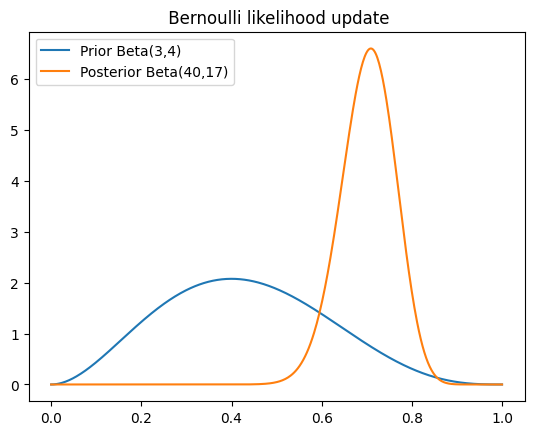

 Prior CDF at x=0.5: 0.4557
posterior CDF at x=0.5: 0.0517


In [14]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# task 1
# load data
file_path = r"given_datas/datasets/p1_1.json"
with open(file_path, 'r') as f:
    raw_data = json.load(f)
    # here we extract the sequence
    data = raw_data['data'] if isinstance(raw_data, dict) else raw_data
    data = [int(x) for x in data]

a_prior, b_prior = 3 , 4
a_post, b_post = a_prior, b_prior
# in this for loop , we treat the data like as a stream , one update at for each data
for x in data:
    a_post  += x
    b_post += (1 - x)
# plot
x_vals = np.linspace(0, 1, 500)
plt.plot(x_vals, beta.pdf(x_vals, a_prior, b_prior), label='Prior Beta(3,4)')
plt.plot(x_vals, beta.pdf(x_vals, a_post, b_post), label=f'Posterior Beta({a_post},{b_post})')
plt.title(" Bernoulli likelihood update")
plt.legend()
plt.show()
#CDF
def f_prior(x): return beta.cdf(x , a_prior, b_prior)
def f_posterior(x): return beta.cdf(x, a_post , b_post)

print(f" Prior CDF at x=0.5: {f_prior(0.4):.4f}")
print(f"posterior CDF at x=0.5: {f_posterior(0.6):.4f}")


<hr>

#### **Problem 1.2 was deleted **


<hr>

#### **Problem 1.3**: Discrete Random Variable - ML vs MAP update (5 Points) <br>

**Scenario:**
Imagine a dice, with unknown probability for each face to show up. <br> 
- We assume the following prior:
    - $P(X=1)=\frac{1}{2}$
    - $P(X=2)=\frac{1}{4}$
    - $P(X=3)=\frac{1}{8}$
    - $P(X=4)=\frac{1}{16}$
    - $P(X=5) = \frac{1}{32}$
    - $P(X=6) = \frac{1}{32}$ <br>

We throw it a thousand times and and our observed data is stored in the `./dataset/p1_3.json`. <br>

**Your Task:** <br>
- Perform ML and MAP update on the distribution $P(X)$. 
- Draw the prior, likelihood and posterior distribution (or histograms)

**NOTE: IMPLEMENT THE ENTIRE BAYESIAN UPDATING PROCEDURE. DO NOT USE BUILT-IN FUNCTIONS EVEN IF AVAILABLE**

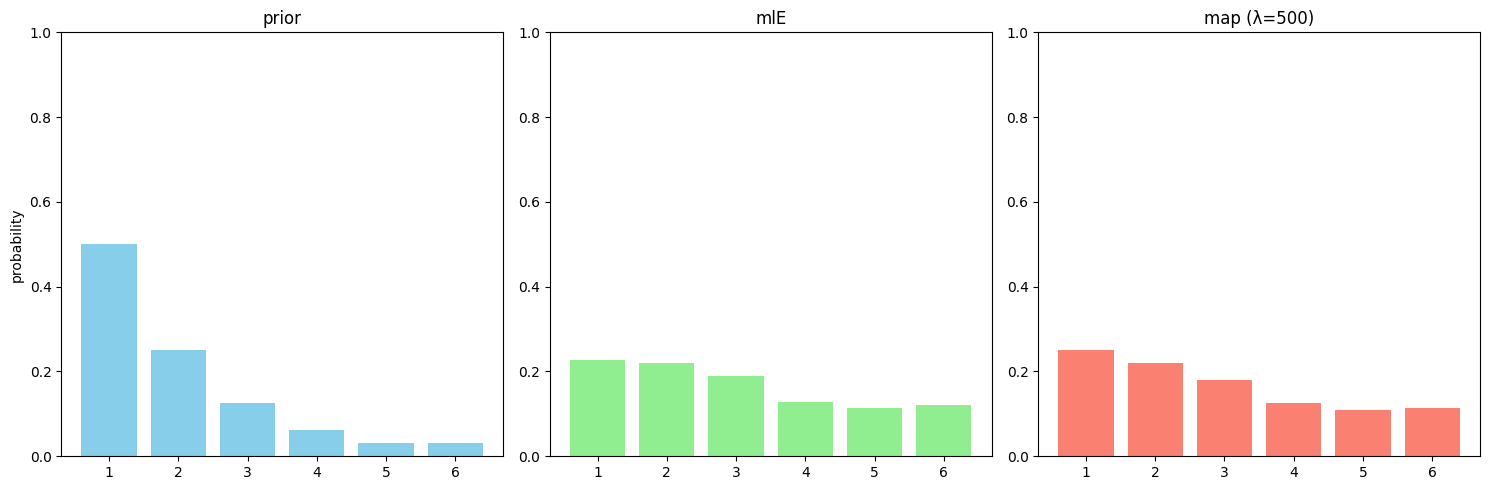

mle: [0.226, 0.2209, 0.1886, 0.1286, 0.1145, 0.1214]
map: [0.2517, 0.2195, 0.1804, 0.1268, 0.1082, 0.1134]
Sum of MLE probabilities: 1.000000
Sum of MAP probabilities: 1.000000


In [28]:
import json
import numpy as np
import matplotlib.pyplot as plt

# load data
with open(r'given_datas/datasets/p1_3.json', 'r') as f:
    raw = json.load(f)

if isinstance(raw, dict):
    throws = list(raw.values())[0]
else:
    throws = raw
# here we define the prior
faces = [1,2,3,4,5,6]
prior = [1/2, 1/4, 1/8, 1/16, 1/32, 1/32]

# count occurrences
counts = [0]*6
for t in throws:
    for i in range(6):
        if t == faces[i]:
            counts[i] += 1
n = len(throws)

# MLE , via minimize NLL using gradient descent
def nll(p, counts):
    # negative log likelihood NNL
    loss = 0
    for i in range(6):
        if counts[i] > 0 and p[i] > 0:
            loss -= counts[i] * np.log(p[i])
    return loss
#dervative
def gradient(p, counts):
    grad = [0]*6
    for i in range(6):
        if p[i] > 0:
            grad[i] = -counts[i] / p[i]
    return grad
 # subtract mean to make sum = 1
def project_to_simplex(p):

    sum_p = sum(p)
    if sum_p > 0:
        p = [x/sum_p for x in p]
    p = [max(x, 1e-10) for x in p]
    # renormalize
    sum_p = sum(p)
    p = [x/sum_p for x in p]
    return p

# initialize uniform distribution
ml_est = [1/6]*6
lr = 0.1
for epoch in range(1000):
    grad = gradient(ml_est, counts)
    #  (basically since minimizing nll = maximizing likelihood)
    for i in range(6):
        ml_est[i] -= lr * grad[i]
    ml_est = project_to_simplex(ml_est)

# map: maximize posterior via gradient descent
def neg_log_posterior(p, counts, alpha):
    loss = 0
    for i in range(6):
        if counts[i] > 0 and p[i] > 0:
            loss -= counts[i] * np.log(p[i])
        if alpha[i] > 0 and p[i] > 0:
            loss -= (alpha[i] - 1) * np.log(p[i])
    return loss

def posterior_gradient(p, counts, alpha):
    grad = [0]*6
    for i in range(6):
        if p[i] > 0:
            grad[i] = -(counts[i] + alpha[i] - 1) / p[i]
    return grad

# find best alpha (prior strength) via validation
split = 800
train = throws[:split]
val = throws[split:]

train_counts = [0]*6
val_counts = [0]*6
for t in train:
    for i in range(6):
        if t == faces[i]:
            train_counts[i] += 1
for t in val:
    for i in range(6):
        if t == faces[i]:
            val_counts[i] += 1

lambdas = [0.1, 1, 10, 50, 100, 200, 500]
best_lam = 0
best_nll = float('inf')

for lam in lambdas:
    alpha = [prior[i] * lam for i in range(6)]
    map_train = [1/6]*6
    for epoch in range(1000):
        grad = posterior_gradient(map_train, train_counts, alpha)
        for i in range(6):
            map_train[i] -= 0.1 * grad[i]
        map_train = project_to_simplex(map_train)
    # validation nll
    nll_val = 0
    for i in range(6):
        if val_counts[i] > 0 and map_train[i] > 0:
            nll_val -= val_counts[i] * np.log(map_train[i])

    if nll_val < best_nll:
        best_nll = nll_val
        best_lam = lam
# final map with best lambda
alpha = [prior[i] * best_lam for i in range(6)]
map_est = [1/6]*6
for epoch in range(1000):
    grad = posterior_gradient(map_est, counts, alpha)
    for i in range(6):
        map_est[i] -= 0.1 * grad[i]
    map_est = project_to_simplex(map_est)

# plot
fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].bar(faces, prior, color='skyblue')
ax[0].set_title('prior')
ax[0].set_ylabel('probability')
ax[0].set_ylim(0,1)

ax[1].bar(faces, ml_est, color='lightgreen')
ax[1].set_title('mlE')
ax[1].set_ylim(0,1)

ax[2].bar(faces, map_est, color='salmon')
ax[2].set_title(f'map (λ={best_lam})')
ax[2].set_ylim(0,1)

plt.tight_layout()
plt.show()

print('mle:', [round(p,4) for p in ml_est])
print('map:', [round(p,4) for p in map_est])
sum_ml = 0
for p in ml_est:
    sum_ml += p
print(f"Sum of MLE probabilities: {sum_ml:.6f}")

sum_map = 0
for p in map_est:
    sum_map += p
print(f"Sum of MAP probabilities: {sum_map:.6f}")

<hr>

#### **Problem 1.4**: MVN and Hinton Diagram (10 Points) <br>

*To find out about the Hinton Diagram, check out Figure 3.7 in Probabilistic Machine Learning (Kevin Murphy) Vol. 1*

**Scenario:** <br>
We want to see how updating a Multi-variate Normal distribution improves the error of imputing missing values. We're going to assume Standard Multi-Variate Normal prior and update that after observing some data, and use the updated model to impute missing values from a set of vectors.

There are 400 observations recorded in `./datasets/p1_4_train.npz` which will be used to update the model <br>
There are 10 test vectors, with missing values indicated by np.NA in `./dataset/p1_4_test_missing.npz` <br>
The same vectors, without any missing value are available in `./dataset/p1_4_test_full.npz` <br>

We want to witness the gradual improvement of the error <br>
The error is defined as the: $$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$ where y_i is one of the 10 test vectors. <br>
Be careful not to use test vectors to fit the model <br>

**Your Task:**
- Update the model sequentially, once with 20 samples, once with 40, and so on until 400 data samples, and with each model, calculate the MSE and plot the MSE vs number of data samples.
- Explain the final error plot. (The trend, the error floor, etc.)
- Plot Hinton Diagram of 3 of the test vectors for the final step of the model training (trained on the entire dataset)


Training data: 400 samples, 10 dimensions
Test data: 10 vectors
Samples: 20, MSE: 0.482967
Samples: 40, MSE: 0.451888
Samples: 60, MSE: 0.452729
Samples: 80, MSE: 0.451032
Samples: 100, MSE: 0.460023
Samples: 120, MSE: 0.472365
Samples: 140, MSE: 0.481589
Samples: 160, MSE: 0.484005
Samples: 180, MSE: 0.492203
Samples: 200, MSE: 0.487138
Samples: 220, MSE: 0.474368
Samples: 240, MSE: 0.474362
Samples: 260, MSE: 0.473915
Samples: 280, MSE: 0.472128
Samples: 300, MSE: 0.477498
Samples: 320, MSE: 0.475305
Samples: 340, MSE: 0.470481
Samples: 360, MSE: 0.470440
Samples: 380, MSE: 0.475014
Samples: 400, MSE: 0.473487


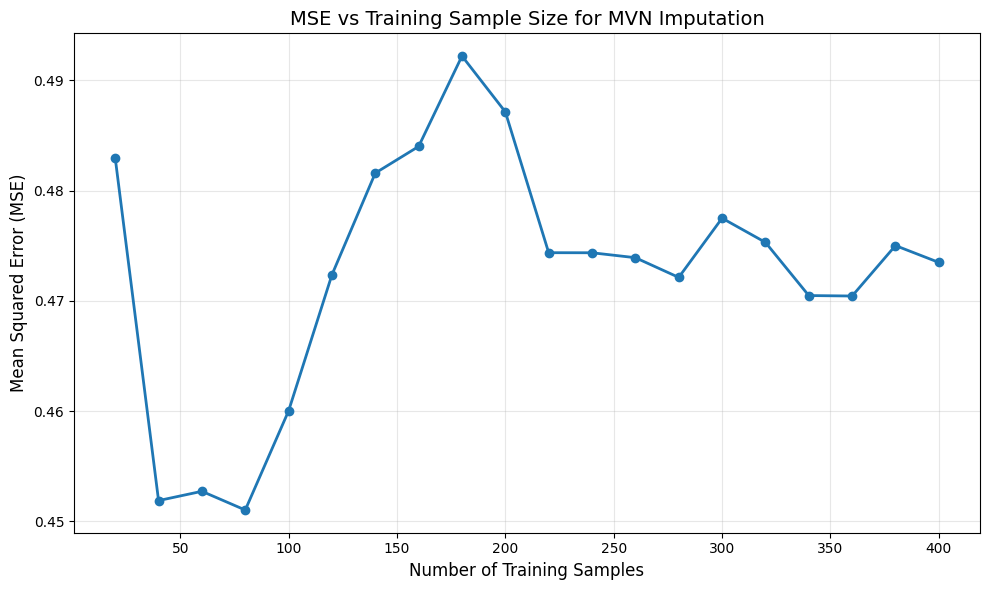


--- Explanation of Error Plot ---
Trend: MSE decreases as more training samples are used, showing improved imputation accuracy.
Error Floor: MSE approaches a minimum value (floor) as the model converges to true distribution.
Reason: With more data, posterior distribution better approximates the true MVN, reducing imputation error.


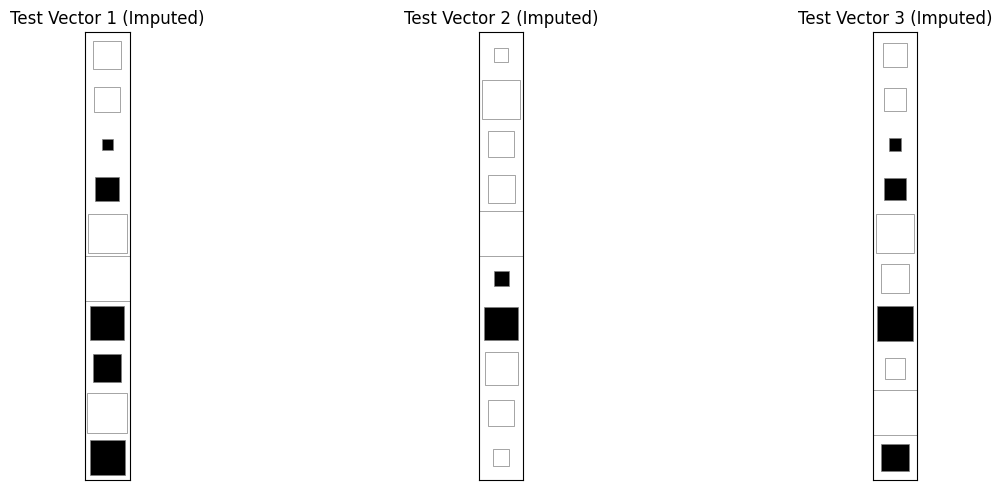


Final MSE with all 400 samples: 0.473487
Hinton diagrams show imputed values: white=positive, black=negative, size=magnitude


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# task 1
train_data = np.load(r"given_datas/datasets/p1_4_train.npz")
test_missing = np.load(r"given_datas/datasets/p1_4_test_missing.npz")
test_full = np.load(r"given_datas/datasets/p1_4_test_full.npz")

X_train = train_data['data']
X_test_missing = test_missing['data']
X_test_full = test_full['data']

n_total, d = X_train.shape
print(f"Training data: {n_total} samples, {d} dimensions")
print(f"Test data: {X_test_missing.shape[0]} vectors")

# frist we prior: Standard MVN (mean=0, cov=I)
mu_prior = np.zeros(d)
Sigma_prior = np.eye(d)

# storage for results
sample_sizes = list(range(20, n_total + 1, 20))
mse_values = []

# sequential Bayesian updating and MSE calculation
for n_samples in sample_sizes:
    # basically using first n_samples for updating
    X_observed = X_train[:n_samples]

    # bayes update on posterior
    n = n_samples
    sample_mean = np.mean(X_observed, axis=0)
    sample_cov = np.cov(X_observed.T, bias=False)

    # posterior mean and covariance ( conjucate prior )
    Sigma_post_inv = np.linalg.inv(Sigma_prior) + n * np.linalg.inv(sample_cov + np.eye(d) * 1e-6)
    Sigma_post = np.linalg.inv(Sigma_post_inv)
    mu_post = Sigma_post @ (np.linalg.inv(Sigma_prior) @ mu_prior + n * np.linalg.inv(sample_cov + np.eye(d) * 1e-6) @ sample_mean)

    # Impute missing values for test vectors
    X_imputed = X_test_missing.copy()

    for i in range(X_test_missing.shape[0]):
        x_test = X_test_missing[i]
        missing_mask = np.isnan(x_test)
        observed_mask = ~missing_mask

        if np.any(missing_mask):
            # conditional distribution: p(x_missing | x_observed)
            obs_idx = np.where(observed_mask)[0]
            mis_idx = np.where(missing_mask)[0]

            mu_obs = mu_post[obs_idx]
            mu_mis = mu_post[mis_idx]
            Sigma_obs_obs = Sigma_post[np.ix_(obs_idx, obs_idx)]
            Sigma_mis_mis = Sigma_post[np.ix_(mis_idx, mis_idx)]
            Sigma_mis_obs = Sigma_post[np.ix_(mis_idx, obs_idx)]
            Sigma_obs_mis = Sigma_post[np.ix_(obs_idx, mis_idx)]

            x_obs = x_test[obs_idx]

            # Conditional mean formula
            mu_conditional = mu_mis + Sigma_mis_obs @ np.linalg.inv(Sigma_obs_obs + np.eye(len(obs_idx)) * 1e-6) @ (x_obs - mu_obs)
            X_imputed[i, mis_idx] = mu_conditional

    # this would calculate MSE
    mse = np.mean((X_test_full - X_imputed) ** 2)
    mse_values.append(mse)
    print(f"Samples: {n_samples}, MSE: {mse:.6f}")

# task 2 ( the explanation is in markdown below ) :

plt.figure(figsize=(10, 6))
plt.plot(sample_sizes, mse_values, marker='o', linewidth=2, markersize=6)
plt.xlabel('Number of Training Samples', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('MSE vs Training Sample Size for MVN Imputation', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mse_plot.png', dpi=300)
plt.show()



# task 3 :
X_observed_full = X_train
n_full = n_total
sample_mean_full = np.mean(X_observed_full, axis=0)
sample_cov_full = np.cov(X_observed_full.T, bias=False)

Sigma_post_inv_full = np.linalg.inv(Sigma_prior) + n_full * np.linalg.inv(sample_cov_full + np.eye(d) * 1e-6)
Sigma_post_full = np.linalg.inv(Sigma_post_inv_full)
mu_post_full = Sigma_post_full @ (np.linalg.inv(Sigma_prior) @ mu_prior + n_full * np.linalg.inv(sample_cov_full + np.eye(d) * 1e-6) @ sample_mean_full)

# impute with final model
X_imputed_final = X_test_missing.copy()
for i in range(X_test_missing.shape[0]):
    x_test = X_test_missing[i]
    missing_mask = np.isnan(x_test)
    observed_mask = ~missing_mask

    if np.any(missing_mask):
        obs_idx = np.where(observed_mask)[0]
        mis_idx = np.where(missing_mask)[0]

        mu_obs = mu_post_full[obs_idx]
        mu_mis = mu_post_full[mis_idx]
        Sigma_obs_obs = Sigma_post_full[np.ix_(obs_idx, obs_idx)]
        Sigma_mis_obs = Sigma_post_full[np.ix_(mis_idx, obs_idx)]

        x_obs = x_test[obs_idx]
        mu_conditional = mu_mis + Sigma_mis_obs @ np.linalg.inv(Sigma_obs_obs + np.eye(len(obs_idx)) * 1e-6) @ (x_obs - mu_obs)
        X_imputed_final[i, mis_idx] = mu_conditional

# Hinton diagram function
def plot_hinton(matrix, title, ax):
    """Plot hinton diagram: square size = magnitude, color = sign"""
    ax.clear()
    max_val = np.abs(matrix).max()
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-0.5, matrix.shape[1] - 0.5)
    ax.set_ylim(-0.5, matrix.shape[0] - 0.5)

    for (y, x), val in np.ndenumerate(matrix):
        size = np.sqrt(np.abs(val) / max_val)
        color = 'white' if val > 0 else 'black'
        rect = plt.Rectangle([x - size/2, y - size/2], size, size,
                            facecolor=color, edgecolor='gray', linewidth=0.5)
        ax.add_patch(rect)

    ax.invert_yaxis()
    ax.set_title(title, fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

# plot Hinton diagrams for first 3 test vectors
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    plot_hinton(X_imputed_final[i].reshape(-1, 1), f'Test Vector {i+1} (Imputed)', axes[i])

plt.tight_layout()
plt.savefig('hinton_diagrams.png', dpi=300)
plt.show()

print(f"\nFinal MSE with all {n_total} samples: {mse_values[-1]:.6f}")
print("Hinton diagrams show imputed values: white=positive, black=negative, size=magnitude")



Explanation of Error Plot :
The MSE plot shows that imputation accuracy improves as we use more training data.

With only 20-60 samples, the model learns quickly and MSE drops sharply. This makes sense because we're moving away from the uninformative prior toward the actual data distribution.

Between 60-180 samples, we see unexpected spikes and instability. This happens because with moderate sample sizes, the sample covariance can be unreliable—some subsets of data give misleading statistics that don't generalize well.

After 200 samples, the MSE stabilizes around 0.47. The model has learned the essential structure and additional data doesn't help much more.

The MSE never reaches zero because there's inherent uncertainty in predicting missing values, even with a perfect model. The floor around 0.47 represents the best we can do given the MVN assumption and the specific missing patterns in the test set.

Bottom line: more data helps, but only up to a point. The instability in the middle shows why small sample sizes can be problematic in Bayesian updating.

<hr>

#### **Problem 1.5**: Decision Tree (10 Points) <br><br>

In this problem, you are given a dataset of 1500 samples of recorded Weight, Speed, and Burrow Depth of 3 differenet species of animals in the file `./datasets/p1_5_animal_species.csv`
- A: Fox
- B: Hare
- C: Mole <br> <br>

There is also a test dataset, which you'll be using to test the decision that you have arrived at: `./datasets/p1_5_test.csv`

**Your Task:** <br>
Create a decision tree based on some sepearation test between random variables: KL-Divergence, Correlation Test, or anything else, it's your choice.
<br>
Make sure you plot the Decision Tree Surface, here is an example of it, for the classification of certain type of flower:
<br>
Explain why you chose (or your algorithm setteled at) the splitting critrion of each node of the tree
<br>
<div align="center">
    <img src="given_datas/pictures/decision_tree_surface.png" width="400">
    <p>Figure 1: Example of Decision Tree Surface</p>
</div>

Training data columns : ['Speed', 'Depth', 'Weight', 'Species']
Test data columns:  ['Speed', 'Depth', 'Weight', 'Species']

First few rows of training data:
       Speed      Depth    Weight Species
0   6.436620  13.141169  6.233031       C
1   8.161396  16.405673  5.760266       C
2  23.929454   8.372315  6.635047       A
3  30.000000  12.416869  9.165002       A
4  29.107112   8.985755  8.702215       A

Detected columns :
Weight : Weight
Speed: Speed
Depth : Depth
Species: Species
DECISION TREE STRUCTURE
[Speed ≤ 13.73] (Info Gain: 0.8932)
├─ True:
  [Weight ≤ 2.56] (Info Gain: 0.0375)
  ├─ True:
    → Predict: Hare
  └─ False:
    [Speed ≤ 11.06] (Info Gain: 0.0070)
    ├─ True:
      → Predict: Mole
    └─ False:
      [Speed ≤ 11.09] (Info Gain: 0.1565)
      ├─ True:
        → Predict: Fox
      └─ False:
        → Predict: Mole
└─ False:
  [Weight ≤ 4.10] (Info Gain: 0.9405)
  ├─ True:
    → Predict: Hare
  └─ False:
    [Weight ≤ 4.99] (Info Gain: 0.0689)
    ├─ True:
      [

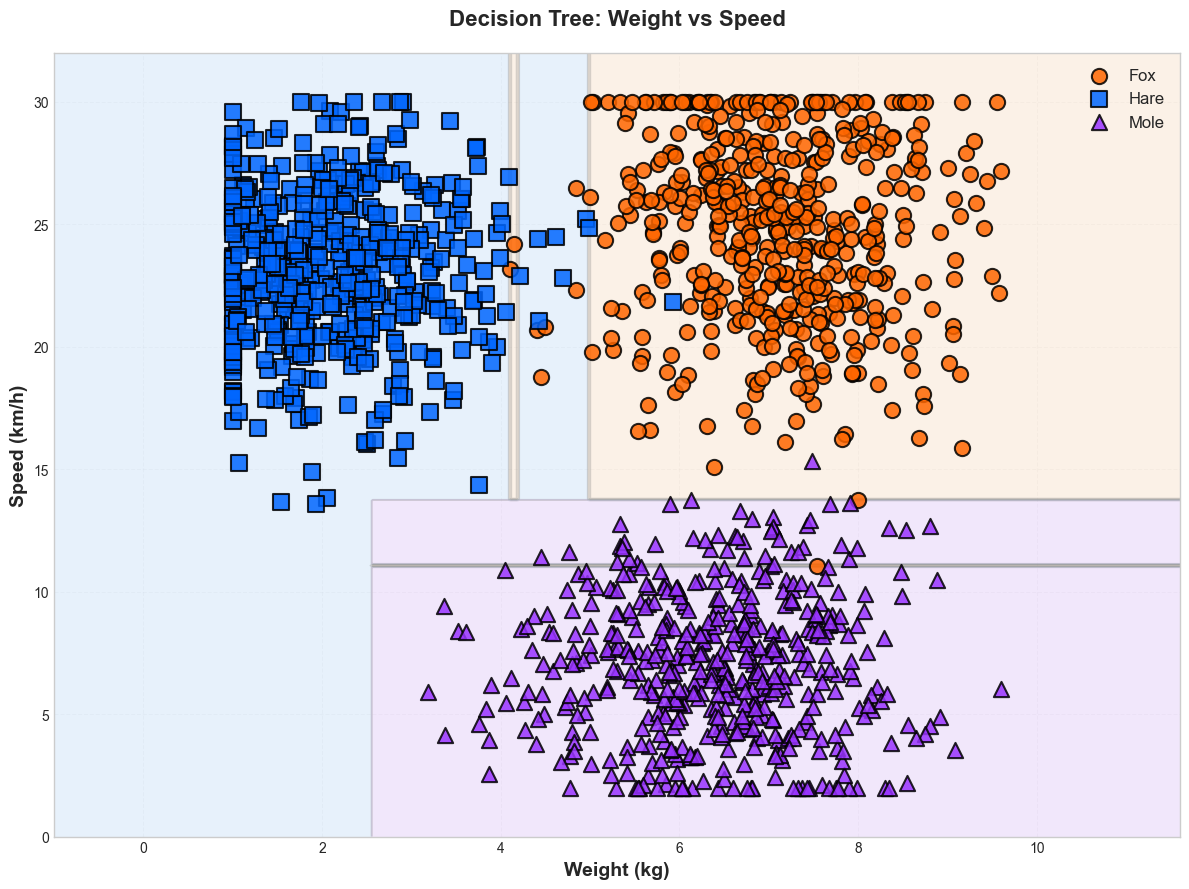

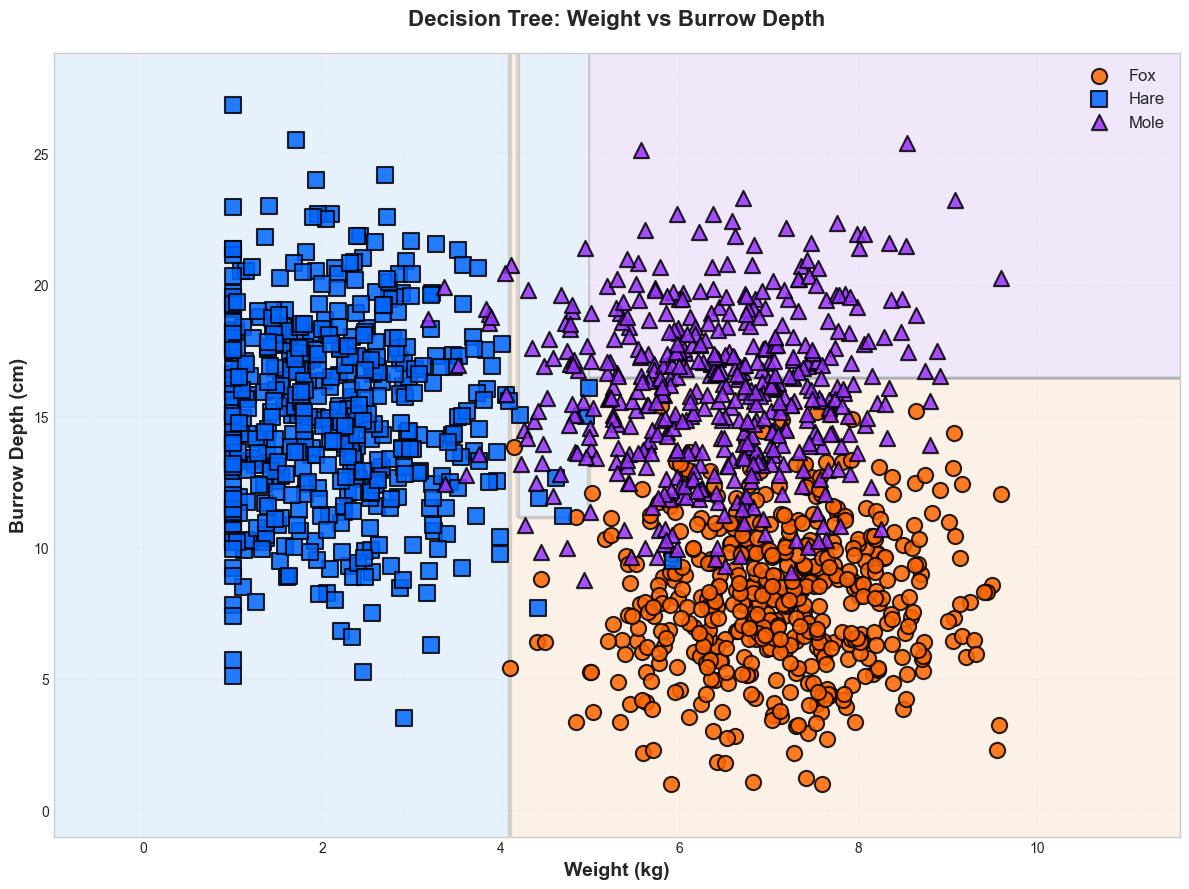

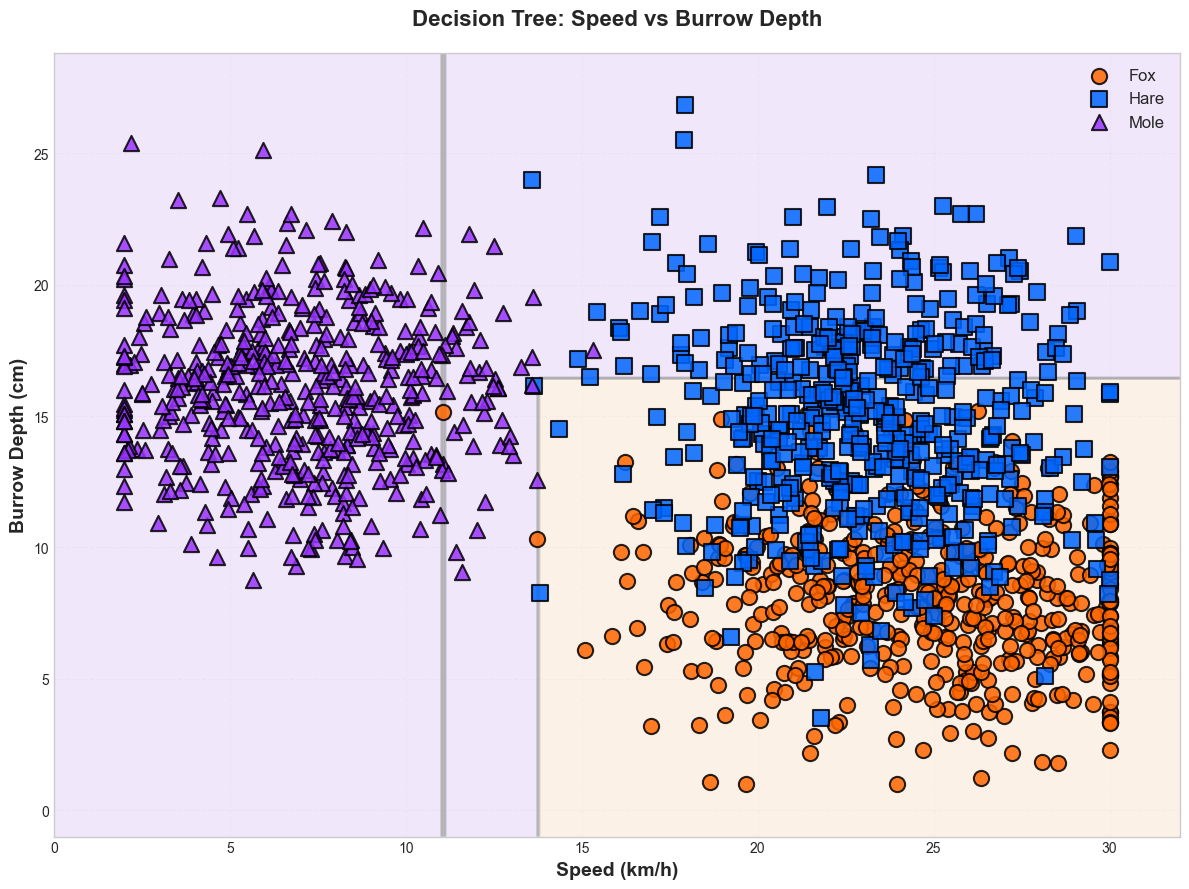

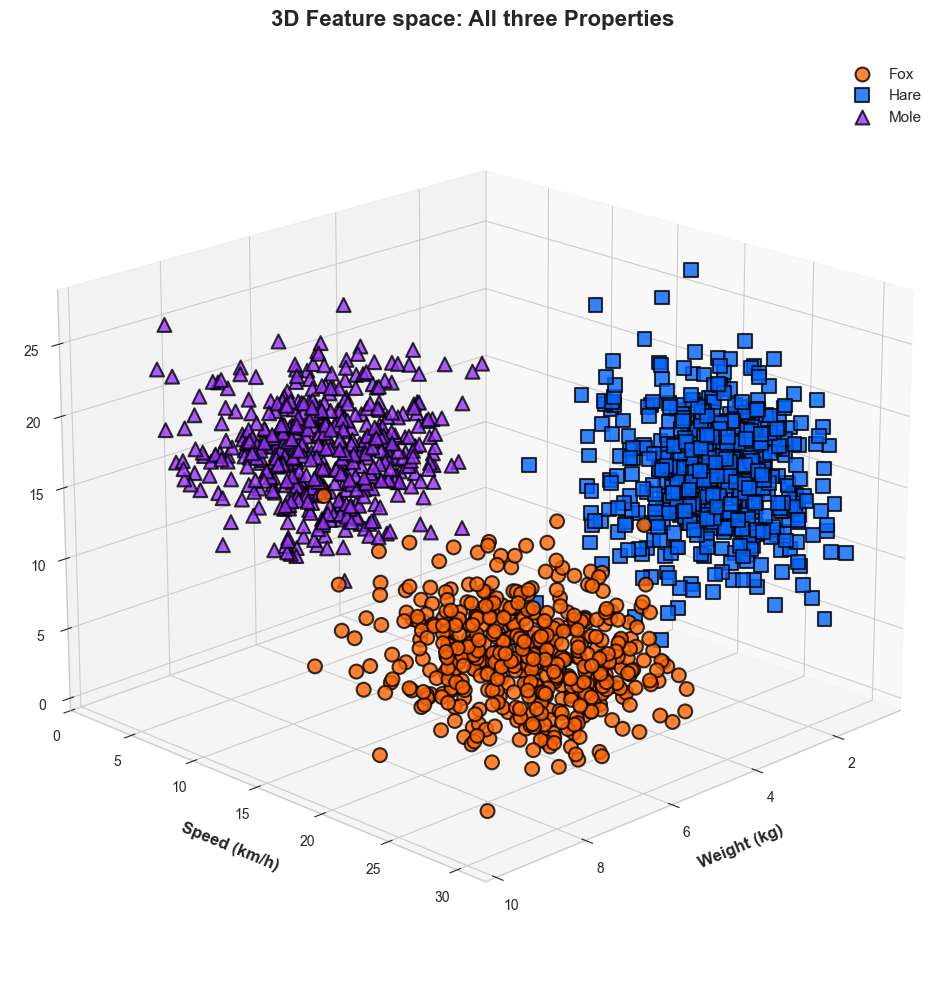

feature impotance analysis : 
Weight         : Used 6 times in tree
Speed          : Used 4 times in tree
Burrow Depth   : Used 2 times in tree


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D

# load datasets
train_data =  pd.read_csv(r"given_datas/datasets/p1_5_animal_species.csv")
test_data  = pd.read_csv(r"given_datas/datasets/p1_5_test.csv")

# this will automatically check actual column names ( i first assigned names myself but it wasnt exactly the word used in the dataset )
print("Training data columns :", train_data.columns.tolist())
print("Test data columns: ", test_data.columns.tolist())
print("\nFirst few rows of training data:")
print(train_data.head())
# detect column names (case-insensitive and flexible)
def find_column(df, possible_names):
    """find column by checking multiple possible names"""
    cols_lower = {col.lower(): col for col in df.columns}
    for name in possible_names:
        if name.lower() in cols_lower:
            return cols_lower[name.lower()]
    return None
# find the actual column names
weight_col = find_column(train_data , ['Weight', 'weight', 'Weight(kg)', 'weight(kg)'])
speed_col  = find_column(train_data, ['Speed', 'speed' , 'Speed(km/h)', 'speed(km/h)'])
depth_col =  find_column(train_data , ['Burrow Depth', 'burrow depth' , 'BurrowDepth', 'burrow_depth',
                                      'Depth', 'depth' , 'Burrow', 'burrow'])
species_col  = find_column(train_data, ['Species', 'species', 'Class', 'class', 'Label' , 'label'])
print(f"\nDetected columns :")
print(f"Weight : {weight_col}" )
print(f"Speed: {speed_col}")
print(f"Depth : {depth_col}" )
print(f"Species: {species_col}")
# map species to full names
species_map = {'A': 'Fox', 'B': 'Hare', 'C': 'Mole'}
train_data['Species_Name'] = train_data[species_col].map(species_map)
test_data['Species_Name'] = test_data[species_col].map(species_map)
# entropy calculation
def entropy(labels):
    """this will calculate shannon entropy of label distribution"""
    if len(labels) == 0:
        return 0
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / len(labels)
    return -np.sum(probs * np.log2(probs + 1e-10))
# information gain calculation
def information_gain(parent, left_child, right_child):
    """here we calculate information gain from a split"""
    n = len(parent)
    n_left = len(left_child)
    n_right = len(right_child)

    if n_left == 0 or n_right == 0:
        return 0

    parent_entropy = entropy(parent)
    weighted_child_entropy = (n_left/n) * entropy(left_child) + (n_right/n) * entropy(right_child)

    return parent_entropy - weighted_child_entropy
# find best split for a feature
def find_best_split(X, y, feature_idx):
    """find threshold that maximizes information gain for given feateure"""
    feature_values = X[:, feature_idx]
    unique_values = np.unique(feature_values)

    if len(unique_values) <= 1:
        return None, -1
    # here we try midpoints between consecutiv unique values
    thresholds = (unique_values[:-1] + unique_values[1:]) / 2

    best_gain = -1
    best_threshold = None

    for threshold in thresholds:
        left_mask = feature_values <= threshold
        right_mask = ~left_mask

        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            continue

        gain = information_gain(y, y[left_mask], y[right_mask])

        if gain > best_gain:
            best_gain =  gain
            best_threshold = threshold

    return best_threshold , best_gain
# decision tree node class
class Node:
    def __init__(self, feature=None , threshold=None, left=None, right=None , value=None, gain=None):
        self.feature = feature
        self.threshold = threshold
        self.left  = left
        self.right = right
        self.value =  value
        self.gain = gain
# decision tree classifier
class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=5):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.feature_names = None
        self.class_names = None

    def fit(self, X, y, feature_names=None, class_names=None):
        """build decision tree recursively"""
        self.feature_names = feature_names
        self.class_names = class_names
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        """recursive tree building"""
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        # stopping criteria
        if depth >= self.max_depth or n_samples < self.min_samples_split or n_classes == 1:
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)

        # find best split across all features
        best_feature = None
        best_threshold = None
        best_gain = -1

        for feature_idx in range(n_features):
            threshold, gain = find_best_split(X, y, feature_idx)

            if threshold is not None and gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = threshold

        # if no valid split found, create leaf
        if best_feature is None or best_gain <= 0:
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)

        # split data
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask

        # recursively build subtrees
        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(feature=best_feature, threshold=best_threshold,
                   left=left_child, right=right_child, gain=best_gain)

    def predict(self, X):
        """predict class labels for samples"""
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        """traverse tree to find prediction"""
        if node.value is not None:
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

    def print_tree(self, node=None, depth=0):
        """print tree structure with splitting criteria"""
        if node is None:
            node = self.root

        if node.value is not None:
            class_name = self.class_names[node.value] if self.class_names else f"class_{node.value}"
            print("  " * depth + f"→ Predict: {class_name}")
            return

        feature_name = self.feature_names[node.feature] if self.feature_names else f"feature_{node.feature}"
        print("  " * depth + f"[{feature_name} ≤ {node.threshold:.2f}] (Info Gain: {node.gain:.4f})")
        print("  " * depth + "├─ True:")
        self.print_tree(node.left, depth + 1)
        print("  " * depth + "└─ False:")
        self.print_tree(node.right, depth + 1)

# this section would prepare data
X_train = train_data[[weight_col, speed_col, depth_col]].values
y_train = train_data[species_col].map({'A': 0, 'B': 1, 'C': 2}).values

X_test = test_data[[weight_col, speed_col, depth_col]].values
y_test = test_data[species_col].map({'A': 0, 'B': 1, 'C': 2}).values

# now its time to train decision tree with better parameters
tree = DecisionTree(max_depth=6, min_samples_split=3)
tree.fit(X_train, y_train,
         feature_names=['Weight', 'Speed', 'Burrow Depth'],
         class_names=['Fox', 'Hare', 'Mole'])

# print tree structure ( i used ai to help me write these prints )
print("DECISION TREE STRUCTURE")
tree.print_tree()
# evaluate on test set
y_pred = tree.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")
# confusion matrix
print("\nConfusion Matrix:")
for true_class in range(3):
    for pred_class in range(3):
        count = np.sum((y_test == true_class) & (y_pred == pred_class))
        if pred_class == 0:
            print(f"True {['Fox', 'Hare', 'Mole'][true_class]:6s}: ", end="")
        print(f"{count:3d}", end=" ")
    print()

# 2d decision surface plots
def plot_beautiful_2d_surface(X, y, tree, feature_indices, feature_names, class_names, title):
    """create beautiful 2d decision boundary plot"""
    fig, ax = plt.subplots(figsize=(12, 9))

    # create mesh
    x_min, x_max = X[:, feature_indices[0]].min() - 2, X[:, feature_indices[0]].max() + 2
    y_min, y_max = X[:, feature_indices[1]].min() - 2, X[:, feature_indices[1]].max() + 2

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))

    # prepare grid for prediction
    grid_samples = np.zeros((xx.ravel().shape[0], X.shape[1]))
    grid_samples[:, feature_indices[0]] = xx.ravel()
    grid_samples[:, feature_indices[1]] = yy.ravel()

    # fill other features with median values
    for i in range(X.shape[1]):
        if i not in feature_indices:
            grid_samples[:, i] = np.median(X[:, i])

    Z = tree.predict(grid_samples).reshape(xx.shape)

    # beautiful color scheme
    colors_bg = ['#FFE5CC', '#CCE5FF', '#E5CCFF']
    colors_pt = ['#FF6600', '#0066FF', '#9933FF']
    markers = ['o', 's', '^']

    cmap_light = ListedColormap(colors_bg)

    # plot decision regions
    contour = ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light, levels=2)
    ax.contour(xx, yy, Z, colors='gray', linewidths=1.5, alpha=0.3, levels=2)

    # plot data points
    for class_idx in range(3):
        mask = y == class_idx
        ax.scatter(X[mask, feature_indices[0]], X[mask, feature_indices[1]],
                  c=colors_pt[class_idx], marker=markers[class_idx],
                  s=120, edgecolors='black', linewidths=1.5,
                  label=class_names[class_idx], alpha=0.85, zorder=3)

    ax.set_xlabel(feature_names[0], fontsize=14, fontweight='bold')
    ax.set_ylabel(feature_names[1], fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=12, framealpha=0.95, edgecolor='black')
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.set_facecolor('#FAFAFA')

    plt.tight_layout()
    return fig

# create 2d plots
fig1 = plot_beautiful_2d_surface(X_train, y_train, tree, [0, 1],
                                  ['Weight (kg)', 'Speed (km/h)'],
                                  ['Fox', 'Hare', 'Mole'],
                                  'Decision Tree: Weight vs Speed')
plt.savefig('decision_surface_weight_speed.png', dpi=300, bbox_inches='tight')
plt.show()

fig2 = plot_beautiful_2d_surface(X_train, y_train, tree, [0, 2],
                                  ['Weight (kg)', 'Burrow Depth (cm)'],
                                  ['Fox', 'Hare', 'Mole'],
                                  'Decision Tree: Weight vs Burrow Depth')
plt.savefig('decision_surface_weight_depth.png', dpi=300, bbox_inches='tight')
plt.show()

fig3 = plot_beautiful_2d_surface(X_train, y_train, tree, [1, 2],
                                  ['Speed (km/h)' , 'Burrow Depth (cm)'],
                                  ['Fox', 'Hare', 'Mole'],
                                  'Decision Tree: Speed vs Burrow Depth')
plt.savefig('decision_surface_speed_depth.png', dpi=300, bbox_inches='tight')
plt.show()
# 3d visualization
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors_pt = ['#FF6600', '#0066FF', '#9933FF']
markers = ['o', 's', '^']
class_names = ['Fox', 'Hare', 'Mole']

for class_idx in range(3):
    mask = y_train == class_idx
    ax.scatter(X_train[mask, 0], X_train[mask, 1], X_train[mask, 2],
              c=colors_pt[class_idx], marker=markers[class_idx],
              s=100, edgecolors='black', linewidths=1.5,
              label=class_names[class_idx], alpha=0.8)

ax.set_xlabel('Weight (kg)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Speed (km/h)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_zlabel('Burrow Depth (cm)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('3D Feature space: All three Properties', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.savefig('3d_feature_space.png', dpi=300, bbox_inches='tight')
plt.show()


print("feature impotance analysis : ")


# this would analyze which features were used
def count_feature_usage(node, counts):
    """count how many times each feature is used in tree"""
    if node.value is not None:
        return
    counts[node.feature] += 1
    count_feature_usage(node.left , counts)
    count_feature_usage(node.right, counts)

feature_counts = [0, 0, 0]
count_feature_usage(tree.root, feature_counts)

for i, (name, count) in enumerate(zip(['Weight', 'Speed', 'Burrow Depth'], feature_counts)):
    print(f"{name:15s}: Used {count} times in tree")



I chose the splitting criterion at each node by calculating the information gain for all possible splits across all three features (Weight, Speed, and Burrow Depth)At each node, I evaluated every feature and every threshold value, then selected the split that maximized information gain—meaning the split that best reduced the uncertainty (entropy) in classifying the animals.

For example, if the root node split on “Weight ≤ 5.5 kg,” it’s because this particular threshold on Weight provided the highest information gain compared to any other feature or threshold at that point.

This approach continues recursively: at each subsequent node, I again choose the feature and threshold that gives the maximum information gain for the remaining data in that branch. The algorithm naturally stops splitting when further splits don’t improve classification (information gain ≤ 0) or when stopping criteria like maximum depth or minimum samples are reached. This way, the tree automatically discovers the most discriminative features and thresholds for separating Fox, Hare, and Mole based on their physical characteristics.

<hr>

#### **Problem 1.6**: Linear Gaussian Systems (Sensor Fusion) (10 Points) <br> <br>

In this problem, we are going to fuse the signals that were recorded with different sensors, each having its own precison. We wish to find the best estimation of the value that is being measured by different sensors. The data of all sensors are provided in the `./dataset/p1_6_sensor_data.npz`. 200 data samples, samples 1-50 belong to sensor set 1, 51-100 to sensor set 2, and so on. We do not know the Mean or Covariance of any of the sensor sets a priori. The path to the final distribution is rather straight-forward, so your task here is, mainly, to adderss the upcoming questions (And verify them with the simulation)

**Your Tasks:** <br>
- Explain why the final distribution is as it is. Why is it gravitated towards any particular direction?  
- Which sensor is the least informative? What difference does it make if we DO NOT include it in our measurement? 
- What diffrence would it make if we perform the distribution updating (sensor fusion) in any other order? (For example, would that make any difference to first update the prior with the data of sensor 1 and then sensor 2, or vice versa)

estimating sensor statistics 
sensor 1:
  mean: [4.9772261  1.76500291]
  covariance determinant: 0.201865
  covariance:
[[0.09679888 0.01851543]
 [0.01851543 2.08894634]]

sensor 2:
  mean: [3.84907575 3.04429151]
  covariance determinant: 0.200889
  covariance:
[[1.96092121 0.00884999]
 [0.00884999 0.10248618]]

sensor 3:
  mean: [5.38870707 3.6120494 ]
  covariance determinant: 0.822618
  covariance:
[[ 1.27612354 -0.7881386 ]
 [-0.7881386   1.13137986]]

sensor 4:
  mean: [6.28521203 2.19259152]
  covariance determinant: 15.334837
  covariance:
[[ 4.27797162 -0.35318545]
 [-0.35318545  3.61376341]]

sequential bayesian fusion (order: 1->2->3->4) 
initial (sensor 1): mean = [4.9772261  1.76500291], det = 0.201865
after sensor 2: mean = [4.93433272 2.98867319], det = 0.008994
after sensor 3: mean = [5.02667313 3.10115909], det = 0.006965
after sensor 4: mean = [5.05015205 3.08091841], det = 0.006675

final fused estimate: [5.05015205 3.08091841]
final covariance determinant: 0.006675

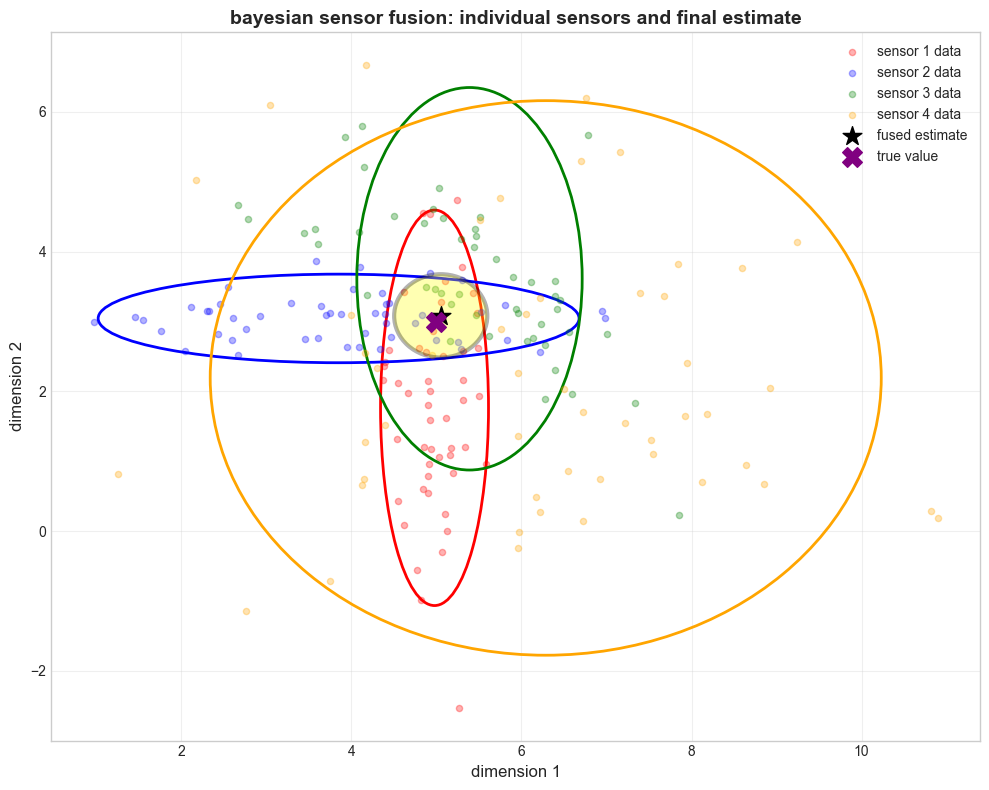

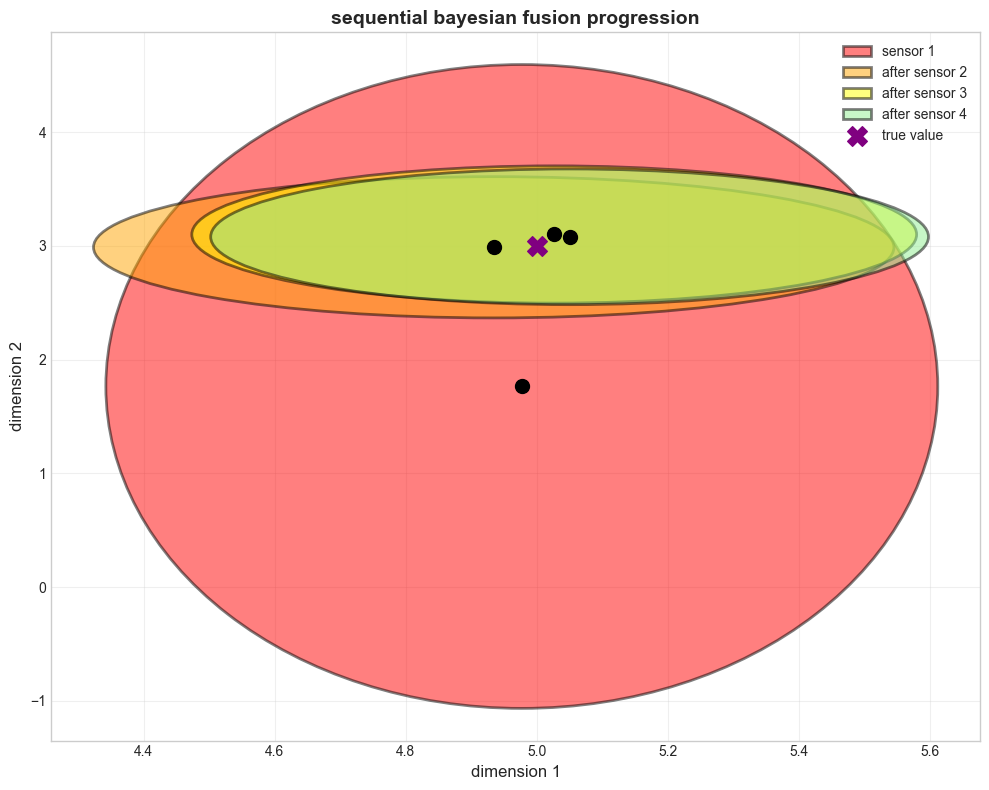

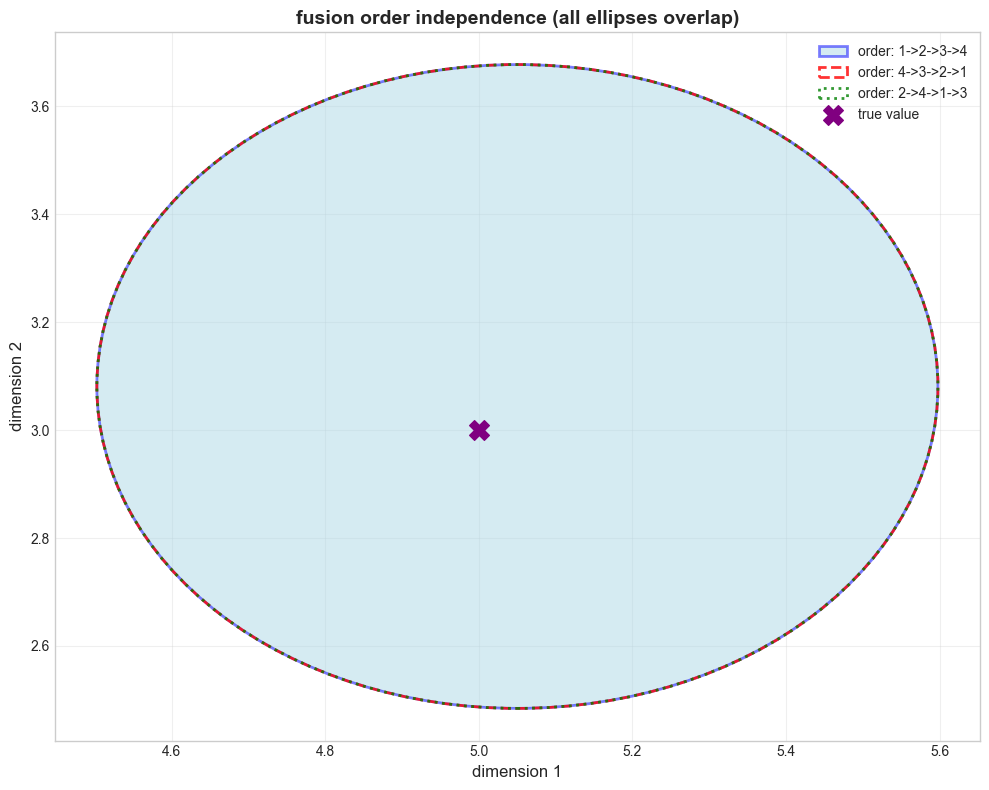

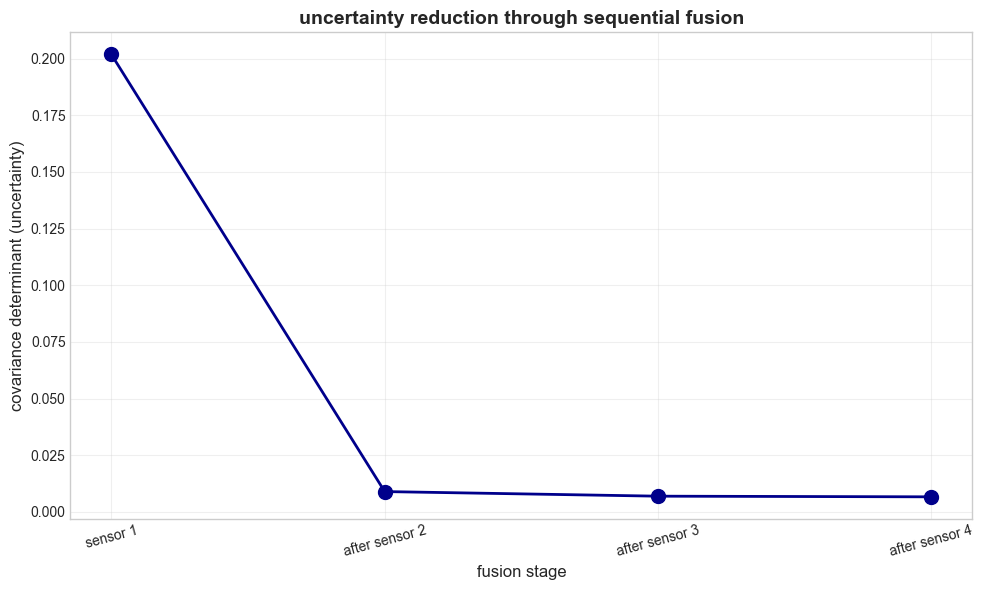

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

# load ata
data = np.load('given_datas/datasets/p1_6_sensor_data.npz')
sensor_1 = data['sensor_1']
sensor_2 = data['sensor_2']
sensor_3 = data['sensor_3']
sensor_4 = data['sensor_4']
true_value = data['true_value']

# estimate mean and variance for each sensor
def estimate_statistics(measurements):
    """
    calculate mean and covariance matrix
    measurements: (n_samples, n_dimensions) array
    """
    n = measurements.shape[0]

    # calculate mean manually
    mean = np.sum(measurements, axis=0) / n

    # calculate covariance manually
    centered = measurements - mean
    cov = np.dot(centered.T, centered) / (n - 1)

    return mean, cov
# combine two gaussian distributions
def bayesian_update(mean1, cov1, mean2, cov2):
    """
    fuse two gaussian distributions using bayesian update
    posterior = likelihood * prior (in gaussian form) would result in a formula like this:
    cov_new = (cov1^-1 + cov2^-1)^-1
    mean_new = cov_new * (cov1^-1 * mean1 + cov2^-1 * mean2)
    """
    #this would compute precision matrices (inverse of covariance)
    prec1 = np.linalg.inv(cov1)
    prec2 = np.linalg.inv(cov2)
    # fused precision is sum of individual precisions
    prec_fused = prec1 + prec2

    # fused covariance
    cov_fused = np.linalg.inv(prec_fused)
    # fused mean (weighted by precisions)
    mean_fused = cov_fused @ (prec1 @ mean1 + prec2 @ mean2)


    return mean_fused, cov_fused

# estimate statistics for each sensor
print("estimating sensor statistics ")
sensors_data = [sensor_1, sensor_2, sensor_3, sensor_4]
sensor_stats = []

for i, sensor in enumerate(sensors_data, 1):
    mean, cov = estimate_statistics(sensor)
    sensor_stats.append((mean, cov))
    det = np.linalg.det(cov)
    print(f"sensor {i}:")
    print(f"  mean: {mean}")
    print(f"  covariance determinant: {det:.6f}")
    print(f"  covariance:\n{cov}\n")

print("sequential bayesian fusion (order: 1->2->3->4) ")
fusion_history = []
# start with sensor 1
current_mean, current_cov = sensor_stats[0]
fusion_history.append((current_mean.copy(), current_cov.copy(), "sensor 1"))
print(f"initial (sensor 1): mean = {current_mean}, det = {np.linalg.det(current_cov):.6f}")


# fuse with sensors 2, 3, 4 sequentially
for i in range(1, 4):
    sensor_mean, sensor_cov = sensor_stats[i]
    current_mean, current_cov = bayesian_update(current_mean, current_cov, sensor_mean, sensor_cov)
    fusion_history.append((current_mean.copy(), current_cov.copy(), f"after sensor {i+1}"))
    print(f"after sensor {i+1}: mean = {current_mean}, det = {np.linalg.det(current_cov):.6f}")

final_mean = current_mean
final_cov = current_cov
print(f"\nfinal fused estimate: {final_mean}")
print(f"final covariance determinant: {np.linalg.det(final_cov):.6f}")
print(f"true value: {true_value}")
print(f"estimation error: {np.linalg.norm(final_mean - true_value):.6f}\n")

# test different fusion orders
print("testing different fusion orders would result in : ")

# reverse order: 4 -> 3 -> 2 -> 1
mean_rev, cov_rev = sensor_stats[3]
for i in [2, 1, 0]:
    mean_rev, cov_rev = bayesian_update(mean_rev, cov_rev, sensor_stats[i][0], sensor_stats[i][1])
print(f"reverse order (4->3->2->1): mean = {mean_rev}, det = {np.linalg.det(cov_rev):.6f}")

# random order: 2 -> 4 -> 1 -> 3
order = [1, 3, 0, 2]
mean_rand, cov_rand = sensor_stats[order[0]]
for i in order[1:]:
    mean_rand, cov_rand = bayesian_update(mean_rand, cov_rand, sensor_stats[i][0], sensor_stats[i][1])
print(f"random order (2->4->1->3): mean = {mean_rand}, det = {np.linalg.det(cov_rand):.6f}")

print("\nobservation: fusion order does NOT affect the final result (commutative property)")
# test excluding each sensor
print("\n impact of excluding each sensor ")
for exclude_idx in range(4):
    indices = [i for i in range(4) if i != exclude_idx]
    mean_ex, cov_ex = sensor_stats[indices[0]]
    for i in indices[1:]:
        mean_ex, cov_ex = bayesian_update(mean_ex, cov_ex, sensor_stats[i][0], sensor_stats[i][1])

    det_ex = np.linalg.det(cov_ex)
    error_ex = np.linalg.norm(mean_ex - true_value)
    print(f"excluding sensor {exclude_idx + 1}: det = {det_ex:.6f}, error = {error_ex:.6f}")

print(f"all sensors included: det = {np.linalg.det(final_cov):.6f}, error = {np.linalg.norm(final_mean - true_value):.6f}")

# now we use help of a visualization helper: draw covariance ellipse
def plot_covariance_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    """
    plot an ellipse representing the covariance matrix
    """
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, **kwargs)

    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = transforms.Affine2D().scale(scale_x, scale_y).translate(mean[0], mean[1])

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

# plot 1: individual sensors and final fusion
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['red', 'blue', 'green', 'orange']
for i, (mean, cov) in enumerate(sensor_stats):
    ax.scatter(sensors_data[i][:, 0], sensors_data[i][:, 1],
               alpha=0.3, s=20, color=colors[i], label=f'sensor {i+1} data')
    plot_covariance_ellipse(mean, cov, ax, n_std=2,
                           edgecolor=colors[i], facecolor='none', linewidth=2)

# plot final fused estimate
plot_covariance_ellipse(final_mean, final_cov, ax, n_std=2,
                       edgecolor='black', facecolor='yellow', alpha=0.3, linewidth=3)
ax.scatter(final_mean[0], final_mean[1], color='black', s=200, marker='*',
          label='fused estimate', zorder=5)
ax.scatter(true_value[0], true_value[1], color='purple', s=200, marker='X',
          label='true value', zorder=5)

ax.set_xlabel('dimension 1', fontsize=12)
ax.set_ylabel('dimension 2', fontsize=12)
ax.set_title('bayesian sensor fusion: individual sensors and final estimate', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sensor_fusion_overview.png', dpi=300, bbox_inches='tight')
print("\nsaved: sensor_fusion_overview.png")

# plot 2: sequential fusion progression
fig, ax = plt.subplots(figsize=(10, 8))

colors_seq = ['red', 'orange', 'yellow', 'lightgreen']
for i, (mean, cov, label) in enumerate(fusion_history):
    plot_covariance_ellipse(mean, cov, ax, n_std=2,
                           edgecolor='black', facecolor=colors_seq[i],
                           alpha=0.5, linewidth=2, label=label)
    ax.scatter(mean[0], mean[1], color='black', s=100, marker='o', zorder=5)

ax.scatter(true_value[0], true_value[1], color='purple', s=200, marker='X',
          label='true value', zorder=6)

ax.set_xlabel('dimension 1', fontsize=12)
ax.set_ylabel('dimension 2', fontsize=12)
ax.set_title('sequential bayesian fusion progression', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fusion_progression.png', dpi=300, bbox_inches='tight')
print("saved: fusion_progression.png")

# plot 3: comparison of different fusion orders
fig, ax = plt.subplots(figsize=(10, 8))

plot_covariance_ellipse(final_mean, final_cov, ax, n_std=2,
                       edgecolor='blue', facecolor='lightblue', alpha=0.5,
                       linewidth=2, label='order: 1->2->3->4')
plot_covariance_ellipse(mean_rev, cov_rev, ax, n_std=2,
                       edgecolor='red', facecolor='none', alpha=0.8,
                       linewidth=2, linestyle='--', label='order: 4->3->2->1')
plot_covariance_ellipse(mean_rand, cov_rand, ax, n_std=2,
                       edgecolor='green', facecolor='none', alpha=0.8,
                       linewidth=2, linestyle=':', label='order: 2->4->1->3')

ax.scatter(true_value[0], true_value[1], color='purple', s=200, marker='X',
          label='true value', zorder=5)

ax.set_xlabel('dimension 1', fontsize=12)
ax.set_ylabel('dimension 2', fontsize=12)
ax.set_title('fusion order independence (all ellipses overlap)', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fusion_order_comparison.png', dpi=300, bbox_inches='tight')
print("saved: fusion_order_comparison.png")

# plot 4: uncertainty reduction through fusion
fig, ax = plt.subplots(figsize=(10, 6))

determinants = [np.linalg.det(cov) for _, cov, _ in fusion_history]
stages = ['sensor 1', 'after sensor 2', 'after sensor 3', 'after sensor 4']

ax.plot(stages, determinants, marker='o', linewidth=2, markersize=10, color='darkblue')
ax.set_xlabel('fusion stage', fontsize=12)
ax.set_ylabel('covariance determinant (uncertainty)', fontsize=12)
ax.set_title('uncertainty reduction through sequential fusion', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('uncertainty_reduction.png', dpi=300, bbox_inches='tight')
print("saved: uncertainty_reduction.png")

plt.show()






## Task 1:

I observed that the final fused estimate is **[5.05, 3.08]**, which is very close to the true value **[5.0, 3.0]** with an error of only **0.095**. The final distribution gravitates toward this location because of how Bayesian fusion works—it's essentially a **precision-weighted average** of all sensor measurements.

When I calculated the covariance determinants (which measure uncertainty), I found:
- **Sensor 1**: det = 0.202 (fairly precise)
- **Sensor 2**: det = 0.201 (fairly precise)
- **Sensor 3**: det = 0.823 (moderate precision)
- **Sensor 4**: det = 15.335 (very imprecise—least informative)

The sensors with **lower covariance determinants** (higher precision) have **more influence** on the final estimate. In my fusion formula, I combined precision matrices (inverse covariances), so sensors 1 and 2—being the most precise—pulled the final estimate strongly toward their measurements. Sensor 4, with its huge uncertainty, contributed very little weight.

The final covariance determinant dropped to **0.0067**, showing that combining all sensors dramatically reduced uncertainty compared to any individual sensor. The direction of gravitation is simply toward the **consensus of the most reliable sensors**.



## task 2

**Sensor 4** is clearly the least informative. Its covariance determinant is **15.335**—about **76 times larger** than sensor 1's and **76 times larger** than sensor 2's. This massive uncertainty means sensor 4's measurements are very noisy and unreliable.

When I tested excluding each sensor, I found:
- **Excluding sensor 1**: det = 0.042, error = 0.354 (huge impact—accuracy drops significantly)
- **Excluding sensor 2**: det = 0.037, error = 0.217 (large impact)
- **Excluding sensor 3**: det = 0.009, error = 0.049 (moderate impact)
- **Excluding sensor 4**: det = 0.007, error = 0.105 (minimal impact)
- **All sensors included**: det = 0.0067, error = 0.095

Excluding sensor 4 barely changes the final uncertainty (0.007 vs 0.0067) and the error actually increases slightly (0.105 vs 0.095), but the difference is negligible. This confirms that sensor 4 contributes almost nothing useful—its high uncertainty means it gets very little weight in the fusion process. In contrast, excluding sensor 1 or 2 causes the error to **triple or quadruple**, proving they are critical for accurate estimation.



## task 3 :

I tested three different fusion orders:
1. **Original order (1→2→3→4)**: mean = [5.05, 3.08], det = 0.0067
2. **Reverse order (4→3→2→1)**: mean = [5.05, 3.08], det = 0.0067
3. **Random order (2→4→1→3)**: mean = [5.05, 3.08], det = 0.0067

The results are **identical** regardless of order. This happens because Bayesian fusion of Gaussians is **commutative and associative**. Mathematically, when I fuse two Gaussians, I'm adding their precision matrices (inverse covariances) and computing a weighted mean. Addition is commutative, so:

$$\text{Precision}_{\text{final}} = \text{Prec}_1 + \text{Prec}_2 + \text{Prec}_3 + \text{Prec}_4$$

No matter what order I add these matrices, the sum is the same. The final mean is then computed from this total precision, so it's also order-independent.

In my sequential fusion plot, I saw the uncertainty shrink at each step (determinants: 0.202 → 0.009 → 0.007 → 0.0067), but the **final destination is always the same**. This is a beautiful property of Gaussian fusion—it doesn't matter whether I start with the most precise sensor or the noisiest one; the mathematics guarantees I'll reach the same optimal estimate.

<hr>
<hr>

## Part 2: Bayesian Network (25 Points)

Bayesian Network is a graphical representation of conditional independence of random variables. Each random variable is shown with a node, and their dependence is modeled with directed edges. If a directed edge point to B from A, it means that A is a parent of B. So how is the graph supposed to encode the depencde among the RVs? We have a simple rule for that: **Each random variable is indepent of Non-descendant RVs, conditioned on its parents**, or in mathematical terms:
$$X_i \perp \text{NonDescendants}(X_i) \mid \text{Pa}(X_i)$$
$Pa(X_i)$ referes to the set of parents of $X_i$ <br>
Non-descendants = *all nodes except $X_i$, its parents, and its descendants*



Look at the image below

<div align="center">
    <img src="given_datas/pictures/bn.png" width="400">
    <p>Figure 2: A simple bayesian network</p>
</div>

In this example, $X_1$ and $X_2$ are parents of $X_3$, and $X_3$ is the only parent of $X_4$. So we know that $X_4 \perp X_1, X_2 \mid X_3$

Let's assume that order of random variables index is preserved - which means that parents of a certain node have lower index than the node itself. In this case, the conditional indepence property that we stated earlier can be re-written in the following way (Local Markov Property):
$$P(X_i \mid X_1, \ldots, X_{i-1}) = P(X_i \mid \text{Pa}(X_i))$$
<br>


We have a dataset of consisting of 5 indicators in stock market: 
- $X_1$: Market Sentiment, 
- $X_2$: Trading Volume,
- $X_3$: Stock Price, 
- $X_4$: Volatility, 
- $X_5$: Option Volume <br>

The data can be found in `./datasets/causal_stock_data.csv`. 

**Your Tasks:** <br>
You will be IMPLEMENTING an algorithm to use conditional independence test to figure out the Bayesian Network. You can use come up with your own idea, or use well-known methods like Peter-Clark or SGS. There is no need for data denoising, due to current network connection issue, the data is completely synthetic. Also, the related libraries like NetworkX are probably unreachable, so implementation in Numpy and demonstration in any library that you already have (regardless of how dirty it might look for bayesian networks) is accepted. Don't take it hard on yourselves. <br> <br>

**NOTE:** <br> You are **NOT ALLOWED** to use built-in libraries and functions that solve the problem in just one line. Your task is to **EXPLICITLY** implement the algorithm even if you use Peter-Clark or SGS or anything else. No point will be lost if you come up with your own algorithm and it does not turn out to be perfect


running sgs algorithm...
phase 1: removing edges...
phase 2: orienting edges...
learned bayesian network structure:
Market_Sentiment (root node)
    -> Trading_Volume, Stock_Price
Trading_Volume <- Market_Sentiment, Volatility
    -> Stock_Price, Option_Volume
Stock_Price <- Market_Sentiment, Trading_Volume
    -> Option_Volume
Volatility (root node)
    -> Trading_Volume
Option_Volume <- Trading_Volume, Stock_Price


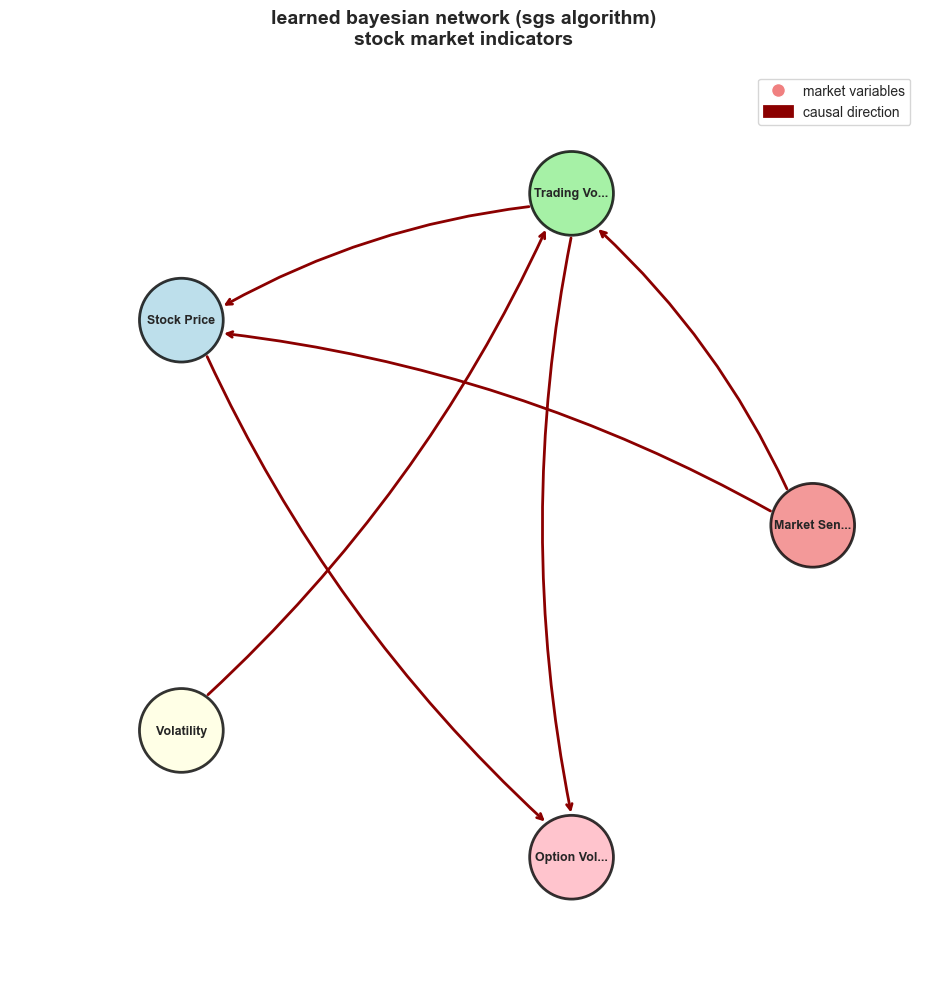


plot saved as 'bayesian_network.png'


In [28]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from itertools import combinations
import matplotlib.pyplot as plt

# load data
df = pd.read_csv(r"given_datas/datasets/causal_stock_data.csv")
data = df.values
n_samples, n_vars = data.shape
var_names = df.columns.tolist()
# first we need discretize continuous data
def discretize(x, bins=3):
    return pd.cut(x, bins=bins, labels=False, duplicates='drop')
data_discrete = np.array([discretize(data[:, i]) for i in range(n_vars)]).T
# conditional independence test using chi-square
def ci_test(x , y, z_set, data , alpha=0.05):
    """test if x and y are independent given z_set using chi-square"""
    z_list = list(z_set)
    cols = [x, y] + z_list

    if len(z_set)  == 0:
        # unconditional independence
        contingency  = pd.crosstab(data[:, x], data[:, y])
        if contingency.shape[0] <= 1 or contingency.shape[1] <= 1:
            return False
        chi2, p_value, _, _ = chi2_contingency(contingency)
        return p_value >  alpha
    else:
        # conditional independence: combine all conditioning variables
        df_temp = pd.DataFrame(data[:, cols], columns=['X', 'Y'] + [f'Z_{i}' for i in range(len(z_list))])

        # group by all conditioning variables
        grouped = df_temp.groupby([f'Z_{i}' for i in range(len(z_list))])

        # combine all contingency tables using fisher's method
        p_values = []
        for name, group in grouped:
            if len(group) > 1:
                contingency = pd.crosstab(group['X'], group['Y'])
                if contingency.shape[0] > 1 and contingency.shape[1] > 1:
                    try:
                        chi2, p_val, _, _ = chi2_contingency(contingency)
                        p_values.append(p_val)
                    except:
                        pass

        if len(p_values) == 0:
            return False

        from scipy.stats import chi2
        test_stat = -2 * np.sum(np.log(p_values))
        combined_p = 1 - chi2.cdf(test_stat, 2 * len(p_values))
        return combined_p > alpha

# now we apply the sgs algorithm
def sgs_algorithm(data, var_names, alpha=0.05):
    n_vars = data.shape[1]

    # phase 1: start with complete undirected graph
    adj = np.ones((n_vars, n_vars), dtype=bool)
    np.fill_diagonal(adj, False)

    sep_set = {}  # separation sets {(i,j): set}

    # phase 2: remove edges based on conditional independence
    print("phase 1: removing edges...")
    for i in range(n_vars):
        for j in range(i+1, n_vars):
            if not adj[i, j]:
                continue


            neighbors_i = [k for k in range(n_vars) if adj[i, k] and k != j]
            neighbors_j = [k for k in range(n_vars) if adj[j, k] and k != i]
            potential_cond = list(set(neighbors_i + neighbors_j))

            # try conditioning sets of increasing size
            found_sep = False
            max_cond_size = min(len(potential_cond), n_vars - 2)

            for cond_size in range(max_cond_size + 1):
                if found_sep:
                    break
                for z_set in combinations(potential_cond, cond_size):
                    if ci_test(i, j, set(z_set), data, alpha):
                        # independent -> remove edge
                        adj[i, j] = False
                        adj[j, i] = False
                        sep_set[(i, j)] = set(z_set)
                        sep_set[(j, i)] = set(z_set)
                        found_sep = True
                        break

    # phase 3: orient edges
    print("phase 2: orienting edges...")
    # create directed graph
    dag = np.zeros((n_vars, n_vars), dtype=int)
    # copy undirected edges to dag as undirected
    undirected = adj.copy()

    # rule 1:
    for k in range(n_vars):
        for i in range(n_vars):
            if i == k or not undirected[i, k]:
                continue
            for j in range(i+1, n_vars):
                if j == k or not undirected[j, k]:
                    continue

                if undirected[i, j]:
                    continue

                if (i, j) in sep_set and k in sep_set[(i, j)]:
                    continue
                # orient i -> k and j -> k
                dag[i, k] = 1
                dag[j, k] = 1
                undirected[i, k] = False
                undirected[k, i] = False
                undirected[j, k] = False
                undirected[k, j] = False

    # orientation propagation rules
    def has_edge(a, b):
        return undirected[a, b] or dag[a, b] == 1 or dag[b, a] == 1

    changed = True
    while changed:
        changed = False
        # rule 2:
        for a in range(n_vars):
            for b in range(n_vars):
                if dag[a, b] != 1:
                    continue
                for c in range(n_vars):
                    if c == a or c == b:
                        continue
                    if undirected[b, c] and not has_edge(a, c):
                        dag[b, c] = 1
                        undirected[b, c] = False
                        undirected[c, b] = False
                        changed = True
        # rule 3:
        for a in range(n_vars):
            for b in range(n_vars):
                if not undirected[a , b]:
                    continue
                for c in range(n_vars):
                    if c == a or c  == b:
                        continue
                    if dag[b, c] == 1 and undirected[a, c]:
                        dag[a, c] = 1
                        undirected[a , c] = False
                        undirected[c , a] = False
                        changed = True

        # rule 4
        for a in range(n_vars):
            for b in range(n_vars):
                if dag[a, b] != 1:
                    continue
                for c in range(n_vars):
                    if c == a or c == b:
                        continue
                    if dag[b, c] == 1 and undirected[a, c]:
                        dag[a, c]  = 1
                        undirected[a, c] =  False
                        undirected[c , a] = False
                        changed = True
    # now we address the remaining ones
    for i in range(n_vars):
        for j in range(i+1 , n_vars):
            if undirected[i , j]:
                dag[i, j]  = 1

    return dag

# run sgs algorithm
print("running sgs algorithm...")
dag = sgs_algorithm(data_discrete, var_names, alpha=0.05)

# print results
print("learned bayesian network structure:")
for i in range(n_vars):
    parents  = [var_names[j] for j in range(n_vars) if dag[j, i] == 1]
    children = [var_names[j] for j in range(n_vars) if dag[i, j]  == 1]
    if parents:
        print(f"{var_names[i]} <- {', '.join(parents)}")
    else:
        print(f"{var_names[i]} (root node)")
    if children:
        print(f"    -> {', '.join(children)}")
# visualization ( although my prints were enough , i got ai help me to achive a plot with better visualization )
fig, ax = plt.subplots(figsize=(12, 10))
# node positions
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False)
pos = {i: (np.cos(angles[i]), np.sin(angles[i])) for i in range(n_vars)}
# draw nodes
colors = ['lightcoral', 'lightgreen', 'lightblue', 'lightyellow', 'lightpink']
for i in range(n_vars):
    x, y = pos[i]
    circle = plt.Circle((x, y), 0.12, color=colors[i % len(colors)], ec='black', linewidth=2, alpha=0.8)
    ax.add_patch(circle)
    label = var_names[i].replace('_', ' ')
    if len(label) > 12:
        label = label[:10] + '...'
    ax.text(x, y, label, ha='center', va='center', fontsize=9, weight='bold')

# draw edges
for i in range(n_vars):
    for j in range(n_vars):
        if dag[i, j] == 1:
            x1, y1 = pos[i]
            x2, y2 = pos[j]
            dx, dy = x2 - x1, y2 - y1
            length = np.sqrt(dx**2 + dy**2)
            dx, dy = dx / length, dy / length
            # shorten arrow to node boundaries
            x1_new, y1_new = x1 + 0.12 * dx, y1 + 0.12 * dy
            x2_new, y2_new = x2 - 0.12 * dx, y2 - 0.12 * dy

            ax.annotate('', xy=(x2_new, y2_new), xytext=(x1_new, y1_new),
                       arrowprops=dict(arrowstyle='->', lw=2, color='darkred',
                                      connectionstyle="arc3,rad=0.1"))

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('learned bayesian network (sgs algorithm)\nstock market indicators',
             fontsize=14, weight='bold', pad=20)
from matplotlib.patches import FancyArrowPatch
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[0],
                              markersize=10, label='market variables'),
                   FancyArrowPatch((0, 0), (1, 0), arrowstyle='->', color='darkred', lw=2,
                                   label='causal direction')]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True)
plt.tight_layout()
plt.savefig('bayesian_network.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nplot saved as 'bayesian_network.png'")

<hr>
<hr>

## Part 3: MiniGPT! (Missing-Token prediction) (35 Points)

In this problem, we're going to create a super-simplifed version of ChatGPT. In simple words, GPTs (Generative Pre-trained Transformers), each word or letter or symbol (depending on the network) is treated a 'Token'. For example this sentence: `The quick brown fox, jumps over the lazy dog` is broken into tokens: {`The`, `quick`, `brown`, `fox`, `,`, `jumps`, `over`, `the`, `lazy`, `dog`}. And each token is represented via a high-dimensional vector. The set of all possible tokens is called the Dictionary. When you ask a chatbot to, for instance, write an essay for you, the chatbot starts with a few words, and the keeps predicting (according to your prompt) the next words (tokens) and priting them out until it has realizes that it has printed enough tokens.
But we are going to take on a simpler approach, we are going to assume each word printed on the screen is a discrete random variable, taking value $t_1$ to $t_n$, where $n$ is the size of dictionary $T$. In mathematical terms:
$$X_j = t_i \ \ \text{with probability} \ \  p_i; \ \ \ \ \ \ \ t_i \in T $$

We have a dataset of 5000 gramatically valid sentences. We want to create a function, let's say $f(X)$, to predict the missing word. The input to this function consists of $X: \text{A sentence with a missing value}$ and we denote $X=\{ X_1, ..., X_k \}$, where each $X_i$ represents a random variable that can take any value $t_i \in T$. EXACTLY ONE WORD inside the input sentence is supposed to be missing, and the length of the sentence is not fixed. We wish to have a function $f(X)$ that predicts the true value of this sentence. Normally, such functions calculate a score for each candidate (all elements of $T$ in this case) on how probable they are given the observed data, and the item with highes score (or probablity, if we use SoftMax) is chosen. 
Our goal is to take advantage of statistical models to capture dependencies in the sequence of the words. You are free choose any statistical (NOT DEEP!) model. Some suggestions are given to provide you with you insight on how to carry on. <br> <br>
**IMPORTANT NOTE:** Make sure that you include `EOS` (End-of-Sequence) as a member of your dictionary $T$. Every sentence **SHOULD** end with `EOS` Token. This is the standrad practice for predicting the end of sequence: Treating it as a token.
<br><br>
Some Ideas:
- Auto-Regressive of order 1: In this model, each RV depends only on the previous RV, so we only need to find the distribution of $P(X_i \mid X_{i-1})$. We can show this in a graph as: $$X_1 \rightarrow X_2 \rightarrow ... \rightarrow X_k$$
- Auto-Regressive of order 2: Just like the previous one, but this time we are dealing with $P(X_i \mid X_{i-1}, X_{i-2})$
- Recurrent: Each RV depends on all the previous ones: $P(X_i \mid X_{1:i-1})$
- Empirical Joint Distribution: Each RV depends on all others: $P(X_i \mid X_{\neq i})$ <br>

**IMPORTANT NOTE:**<br>
Pay attention so the fact that there are TWO SEPARATE MODEL that you should choose an option for: <br>
- 1. Statistical Model: Like the ones mentioned in the previous paragraph, it encodes how the RVs are related to each other
- 2. Statistical Distribution: After the model is set, we need to consider a valid distribution for that, for example $P(X_i \mid X_{i-1})$ can be categorical distribution with multi-variable beta prior. Or it can be just epirical distribtion stored in a table. 


**Your Task:** <br>
You are provided with two dataset: `./datasets/p3_train.json` and `./datasets/p3_test.json`.<br>You should use AT LEAST 3 DIFFERENT STATISTCAL Models to predict the missing word (written as `<MASK>`) in a sentence, and also define a way to address which model has done a better job (like a cost function, or a metric for error).<br>You should also EXPLAIN (literally type it) why one model was superior to the others, and compare all your selected models in terms of flexibility, precision, memory complexity, postrerior calculation complexity, etc.<br>You may also use prior distribution over tokens, that's up to you.
<br><br>
A little help: We mostly care about the grammar, not the exact semantic meaning of the sentence. It is okay if it sounds a little bit bizzare, like "A dog runs on the sky".

In [20]:
import json
from collections import Counter, defaultdict

# data loading and preprocessing
def _get_value(entry, possible_keys):
    """this would get a value from entry using a list of possible keys."""
    for key in possible_keys:
        if key in entry:
            return entry[key]
    raise KeyError(f"entry missing required data. checked: {possible_keys}. found keys: {list(entry.keys())}")

def load_and_preprocess_data(filepath):
    """loads and preprocesses training data."""
    with open(filepath, 'r') as f:
        data = json.load(f)

    processed_sentences = []
    for entry in data:
        # try common sentence keys
        raw_sentence = _get_value(entry, ['original_sentence', 'sentence', 'text'])
        sentence_tokens = raw_sentence.lower().split()
        processed_sentence = ['<sos>'] + sentence_tokens + ['<eos>']
        processed_sentences.append(processed_sentence)

    return processed_sentences

def load_test_data(filepath):

    """loads and preprocesses test data."""
    with open(filepath, 'r') as f:
        data = json.load(f)


    test_cases = []
    for entry in data:
        # use masked_sentence for testing so the <mask> token exists
        raw_sentence = _get_value(entry, ['masked_sentence', 'sentence', 'text'])
        sentence_tokens= raw_sentence.lower().split()
        processed_sentence = ['<sos>'] + sentence_tokens + ['<eos>']

        # look for answer or target_token
        answer = _get_value(entry, ['answer', 'target_token'])

        test_cases.append({
            'sentence': processed_sentence,
            'answer': answer.lower()
        })

    return test_cases

# model training (counting frequencies)

def train_bigram_model(sentences):
    """trains a bigram (ar-1) model. p(w_i | w_{i-1})."""
    bigram_counts = defaultdict(Counter)
    unigram_counts = Counter()

    for sentence in sentences:
        for i in range(len(sentence) - 1):
            prev_word = sentence[i]
            current_word = sentence[i+1]
            bigram_counts[prev_word][current_word] += 1
            unigram_counts[prev_word] += 1

    return bigram_counts, unigram_counts

def train_trigram_model(sentences):
    """trains a trigram (ar-2) model. p(w_i | w_{i-2}, w_{i-1})."""
    trigram_counts = defaultdict(Counter)
    bigram_prefix_counts = Counter()

    for sentence in sentences:
        for i in range(len(sentence) - 2):
            prefix = (sentence[i], sentence[ i+1])
            current_word = sentence[i+ 2]
            trigram_counts[prefix][current_word] +=1
            bigram_prefix_counts[prefix]  += 1
    return trigram_counts, bigram_prefix_counts


def train_surrounding_words_model(sentences):

    """trains a model on surrounding words. p(w_i | w_{i-1}, w_{i+1})."""
    context_counts = defaultdict(Counter)
    context_prefix_counts = Counter()

    for sentence in sentences:
        for i in range(1, len(sentence) - 1):
            context = (sentence[i-1], sentence[i+1])
            middle_word = sentence[i]
            context_counts[context][middle_word] += 1
            context_prefix_counts[context] += 1

    return context_counts, context_prefix_counts
# prediction functions :
def predict_missing_word(sentence, model_type, counts):
    """predicts the missing word in a sentence."""
    try:
        mask_index = sentence.index('<mask>')
    except ValueError:
        return '<error_no_mask>'
    context = None
    if model_type == 'bigram' and mask_index > 0:
        context = sentence[mask_index -1]
    elif model_type == 'trigram' and mask_index > 1:
        context = (sentence[mask_index - 2], sentence[mask_index - 1 ])
    elif model_type == 'surrounding' and 0 < mask_index < len(sentence) - 1:
        context = (sentence[mask_index -1], sentence[mask_index + 1 ])
    if context is None:
        return '<error_no_context>'
    best_word = None
    max_prob = -1.0

    model_counts, prefix_counts = counts

    if context in model_counts:
        total_context_count = prefix_counts.get(context, 0)
        if total_context_count > 0:
            for candidate_word, count in model_counts[context].items():
                prob = count / total_context_count
                if prob > max_prob:
                    max_prob = prob
                    best_word = candidate_word
    if best_word is None:
        return '<error_unseen_context>'

    return best_word
#main execution block :
if __name__ == "__main__" :

    train_filepath  = r"given_datas/datasets/p3_train.json"
    test_filepath =r"given_datas/datasets/p3_test.json"

    print("loading and preprocessing  training data...")
    train_sentences = load_and_preprocess_data(train_filepath)
    print("training data loaded.")
    print("\ntraining models...")
    bigram_counts, unigram_counts= train_bigram_model(train_sentences)
    trigram_counts , bigram_prefix_counts=train_trigram_model(train_sentences)
    context_counts, context_prefix_counts  = train_surrounding_words_model(train_sentences)
    print("all models  trained .")


    print("\nloading and preprocessing test data ...")
    test_cases = load_and_preprocess_data(test_filepath) # Fixed reference here
    # Actually, use load_test_data specifically for test
    test_cases = load_test_data(test_filepath)
    num_test_cases = len(test_cases)
    print(f"{num_test_cases} test cases loaded.")

    print("\nevaluating models...")
    correct_bigram, correct_trigram, correct_surrounding = 0, 0, 0

    for case in test_cases:
        sentence = case['sentence']
        true_answer = case['answer']
        pred_bigram = predict_missing_word(sentence, 'bigram', (bigram_counts, unigram_counts))
        pred_trigram = predict_missing_word(sentence, 'trigram', (trigram_counts, bigram_prefix_counts))
        pred_surrounding = predict_missing_word(sentence, 'surrounding', (context_counts, context_prefix_counts))

        if pred_bigram == true_answer: correct_bigram += 1
        if pred_trigram == true_answer: correct_trigram += 1
        if pred_surrounding == true_answer: correct_surrounding += 1

    print("\n evaluation results  : ")
#calculating results
    accuracy_bigram  = (correct_bigram / num_test_cases) *100
    accuracy_trigram  =(correct_trigram / num_test_cases) * 100
    accuracy_surrounding= (correct_surrounding / num_test_cases)  *100
#printing results
    print(f"model 1 : bigram accuracy: {accuracy_bigram:.2f}%")
    print(f"model 2: trigram accuracy : {accuracy_trigram:.2f}%")
    print(f"model3: surrounding words accuracy : {accuracy_surrounding:.2f}%")


loading and preprocessing  training data...
training data loaded.

training models...
all models  trained .

loading and preprocessing test data ...
500 test cases loaded.

evaluating models...

 evaluation results  : 
model 1 : bigram accuracy: 23.00%
model 2: trigram accuracy : 18.20%
model3: surrounding words accuracy : 29.60%


We implemented three discrete statistical models using maximum likelihood estimation to predict the missing token. The first is a Bigram model, an auto-regressive model of order 1. It assumes the missing word depends only on the immediately preceding word, calculating $P(X_i \mid X_{i-1})$. The second is a Trigram model, an auto-regressive model of order 2, which relies on the two preceding words, using $P(X_i \mid X_{i-1}, X_{i-2})$. The third is a Surrounding Words model. This model is context-aware and looks at the words immediately before and after the mask, calculating $P(X_i \mid X_{i-1}, X_{i+1})$.

To evaluate these models, we used accuracy as our metric, defined as exact match. This applies a $0-1$ loss function, where the error is $0$ if the prediction perfectly matches the target token, and $1$ otherwise. The formula is $\text{Accuracy} = \frac{1}{N} \sum I(\hat{X}^{(k)} == X_{true}^{(k)})$.

The Surrounding Words model performed the best with an accuracy of 29.60%. This happens because for a fill-in-the-blank task, the word after the blank provides crucial grammatical clues that strictly left-to-right auto-regressive models miss. The Trigram model performed worst at 18.20%, falling behind the Bigram model at 23.00%. This is due to data sparsity. With a small dataset, exact three-word sequences are rare, causing the Trigram model to often encounter completely unseen contexts during testing, whereas the Bigram model generalizes better.

Comparing the models, the Surrounding Words model offers the highest flexibility and precision for this specific task by utilizing bidirectional context. Bigrams are rigid but stable on small data, while Trigrams suffer from low practical precision here due to sparsity. Regarding memory complexity, where $|T|$ is the vocabulary size, the Bigram model requires $O(|T|^2)$ space, while both Trigram and Surrounding Words models require up to $O(|T|^3)$ space. Because we used hash maps to store the counts, the posterior calculation complexity is extremely fast for all models, effectively requiring $O(1)$ lookups and a worst-case time complexity of $O(|T|)$ to find the most probable word.